In [1]:
import subprocess
import sys
import os
import time
import numpy as np
import math
from scipy import stats
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd
from seaborn import violinplot

# Сначала тестовые ячейки чтобы понять что все делаем правильно для одного конкретного $N$

Задаем начальные параметры генерации:

In [257]:
cpp_gen = "./setgen"    # путь к скомпилированной C++ программе
filename = "numbers.txt"  # файл, в который C++ программа пишет результат
N = 10000;                   # размер выборки
distrib = "uni";                # вид распределения: uni, exp, norm, lap, gam, 2norm
args = [0, 1]                     # аргументы
seed = 42

Генерируем выборку:

In [258]:
input_args = list(map(str, [N, distrib, filename, seed, *args]))
command = [cpp_gen] + input_args
process = subprocess.run(
    command,
    text=True,
    stdout=subprocess.PIPE
)

In [259]:
with open("numbers/" + filename, 'r', encoding='utf-8') as f:
    file = f.read()
file = list(map(float, file.split()))
data = pd.Series(file)

Теперь преобразуем (то есть файл с данными преобразуется в файл со статистикой)

In [260]:
cpp_executable = "./triang_transform"
filename = "numbers.txt"
W = 100;
delta = 0.1;

In [261]:
input_args = list(map(str, [W, delta, filename]))
command = [cpp_executable] + input_args
process = subprocess.run(
    command,
    text=True,
    stdout=subprocess.PIPE
)

In [262]:
with open("numbers/" + filename, 'r', encoding='utf-8') as f:
    file = f.read()
file = list(map(float, file.split()))
data = pd.Series(file).to_frame(name="result")

И создаем DF с этой самой статистикой, но уже нормализованной

In [263]:
data["cummean"] = data.result.cumsum() / (data.index + 1)
data["ctrresult"] = data.result - data.cummean
data["cumstd"] = np.sqrt((data.ctrresult ** 2).cumsum() / (data.index + 1))
data["normilized"] = data.ctrresult / data.cumstd
data["normilized"] = data["normilized"].fillna(0)

In [264]:
data.tail(5)

,result,cummean,ctrresult,cumstd,normilized
9995,4381.0,4492.814626,-111.814626,599.135634,-0.186627
9996,4354.0,4492.800740,-138.800740,599.107276,-0.231679
9997,4468.0,4492.798260,-24.798260,599.077365,-0.041394
9998,4322.0,4492.781178,-170.781178,599.049842,-0.285087
9999,4298.0,4492.761700,-194.761700,599.023055,-0.325132


<Axes: >

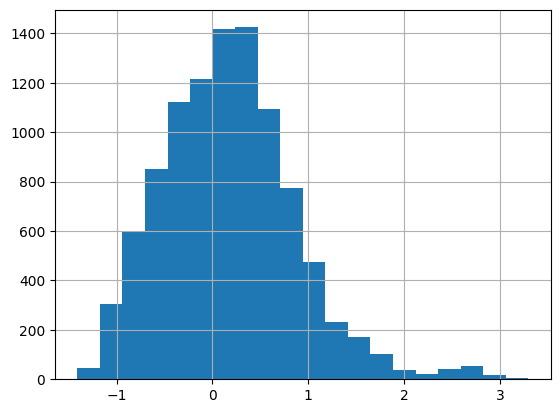

In [265]:
data.normilized.hist(bins=20)

# А теперь то же самое, но сразу для нескольких $N$

In [281]:
cpp_gen = "./setgen"    # путь к скомпилированной C++ программе
filename = "numbers.txt"  # файл, в который C++ программа пишет результат
Ns = [1000, 5000, 10000, 50000, 100000, 500000];                   # размер выборки
distrib = "uni";                # вид распределения: uni, exp, norm, lap, gam, 2norm
args = [0, 1]                     # аргументы
seed = 45
cpp_executable = "./triang_transform"
W = 100;
delta = 0.1;
df = pd.DataFrame(columns=["normilized", "N"])

In [282]:
for N_ in Ns:
    input_args = list(map(str, [N_, distrib, filename, seed, *args]))
    command = [cpp_gen] + input_args
    process = subprocess.run(
        command,
        text=True,
        stdout=subprocess.PIPE
    )
    with open("numbers/" + filename, 'r', encoding='utf-8') as f:
        file = f.read()
    file = list(map(float, file.split()))
    data = pd.Series(file)
    input_args = list(map(str, [W, delta, filename]))
    command = [cpp_executable] + input_args
    process = subprocess.run(
        command,
        text=True,
        stdout=subprocess.PIPE
    )
    with open("numbers/" + filename, 'r', encoding='utf-8') as f:
        file = f.read()
    file = list(map(float, file.split()))
    data = pd.Series(file).to_frame(name="result")
    data["cummean"] = data.result.cumsum() / (data.index + 1)
    data["ctrresult"] = data.result - data.cummean
    data["cumstd"] = np.sqrt((data.ctrresult ** 2).cumsum() / (data.index + 1))
    data["normilized"] = data.ctrresult / data.cumstd
    data["normilized"] = data["normilized"].fillna(0)
    data["N"] = str(N_)
    df = pd.concat([df] + [data[["normilized", "N"]]], ignore_index=True)

/var/folders/lj/28jgzr052fj95v92y4vr_bh40000gn/T/ipykernel_35331/828756694.py:30: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df] + [data[["normilized", "N"]]], ignore_index=True)


In [283]:
df.tail(5)

,normilized,N
665995,-1.498774,500000
665996,-1.498770,500000
665997,-1.452683,500000
665998,-1.354232,500000
665999,-1.463148,500000


<Axes: xlabel='normilized', ylabel='N'>

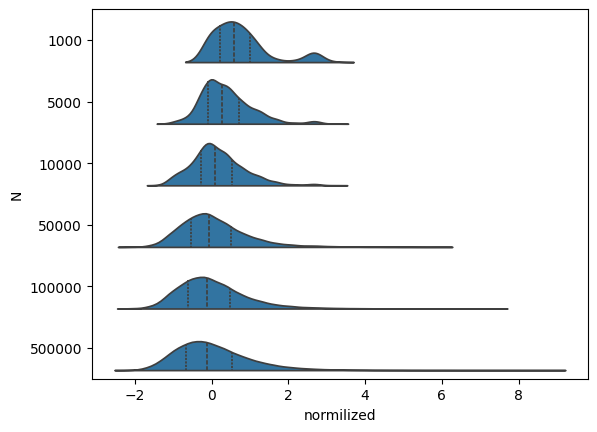

In [284]:
violinplot(data=df, x = "normilized", y = "N", split="True", inner="quart", gap = 0.1)